# Χαρτογράφηση Αντίληψης Επωνυμίας με Ανάλυση Αντιστοιχιών (PROC CORRESP)

## Σύνοψη για Στελέχη

Μια ομάδα έρευνας αγοράς διεξάγει μια έρευνα αντίληψης επωνυμίας-ανά-χαρακτηριστικό σε τέσσερις καθιερωμένες επωνυμίες streaming-media και χρησιμοποιεί το **PROC CORRESP** για να μετατρέψει τον προκύπτοντα πίνακα διασταύρωσης σε έναν δισδιάστατο αντιληπτικό χάρτη. Η συσχέτιση επωνυμίας x χαρακτηριστικού είναι ισχυρή και υπαρκτή: ο έλεγχος ανεξαρτησίας χ-τετραγώνου είναι **63.15 με 15 βαθμούς ελευθερίας (p < 0.0001)**, με **V του Cramer = 0.4588**. Η ανάλυση αντιστοιχιών συμπυκνώνει αυτή τη συσχέτιση σε δύο άξονες που μαζί εξηγούν το **100%** της αδράνειας του πίνακα — **75.0%** στη Διάσταση 1 και **25.0%** στη Διάσταση 2 — οπότε ο δισδιάστατος χάρτης είναι μια πλήρης, πιστή σύνοψη.

Ο χάρτης διαχωρίζει έναν πόλο **premium περιεχομένου** (CineNow, αγκυρωμένο στα *Πρωτότυπα* και *Περιεχόμενο*) από ένα σύμπλεγμα **αξίας/αξιοπιστίας** (Streamly και BingeBox κοντά στα *Προσιτό* και *Αξιόπιστο*) και μια γωνία **μοδάτου** (PixelPlay κοντά στο *Μοντέρνο*). Ένας αναδυόμενος διεκδικητής, η **NovaCast**, προβάλλεται στη συνέχεια ως *συμπληρωματικό* σημείο — δεν επηρεάζει τους άξονες — και προσγειώνεται κοντά στην αρχή των αξόνων, γέρνοντας ελαφρώς προς την πλευρά Μοντέρνο / Ευχρηστία, δηλαδή ένας ακόμη αδιαφοροποίητος νεοεισερχόμενος.

## Πηγές Δεδομένων

| Σύνολο δεδομένων | Γραμμές | Βασικές Μεταβλητές | Περιγραφή |
|---------|------|---------------|-------------|
| `perception` | 100 (συσχετίσεις ερωτώμενου x χαρακτηριστικού, όριο λειτουργίας χωρίς άδεια) | `Brand` (char), `Attribute` (char) | Συνθετική έρευνα: κάθε ερωτώμενος ονομάζει την επωνυμία streaming που συσχετίζει περισσότερο με καθένα από έξι χαρακτηριστικά. Οι συγγένειες επωνυμίας κωδικοποιούνται ως πιθανότητες κατηγορίας `RAND("Table", ...)` ώστε ο πίνακας συνάφειας να έχει ρεαλιστική, μη ομοιόμορφη συσχέτιση. |
| `survey_counts` | 24 (4 επωνυμίες x 6 χαρακτηριστικά) | `Brand`, `Attribute`, `Count` | Προ-συγκεντρωμένα κελιά πίνακα συνάφειας από το `perception` μέσω PROC FREQ — η σταθμισμένη είσοδος για την εκτέλεση CA με συμπληρωματικό σημείο. |
| `ca_coords`, `ca_coords_sup` | 10 / 11 | `_TYPE_`, `_NAME_`, `Dim1`, `Dim2` | Σύνολα δεδομένων συντεταγμένων `OUTC=` που γράφτηκαν από το PROC CORRESP· το δεύτερο προσθέτει το προβεβλημένο σημείο NovaCast και οδηγεί τον αντιληπτικό χάρτη. |

Καθιερωμένες επωνυμίες: **Streamly, PixelPlay, CineNow, BingeBox**· διεκδικητής **NovaCast** (προβεβλημένος ως συμπληρωματικό σημείο). Χαρακτηριστικά: Προσιτό, Περιεχόμενο, Ευχρηστία, Πρωτότυπα, Αξιόπιστο, Μοντέρνο. Ο σπόρος `streaminit(20260531)` καθιστά τα δεδομένα αναπαραγώγιμα.

> **Σημείωση για το μέγεθος δείγματος.** Αυτό το περιβάλλον εκτελείται χωρίς άδεια, οπότε η έξοδος του βήματος DATA περιορίζεται στις 100 παρατηρήσεις. Η έρευνα επομένως καταλήγει σε έναν πίνακα συνάφειας 4x6 που αθροίζει 100 συσχετίσεις ερωτώμενου-χαρακτηριστικού — μικρό, αλλά με γνήσια δομή συσχέτισης (χ-τετράγωνο p < 0.0001) που η ανάλυση αντιστοιχιών ανακτά καθαρά.

## Τι κάνει εδώ η ανάλυση αντιστοιχιών

Όταν μια έρευνα παρακολούθησης επωνυμίας ρωτά τους καταναλωτές ποια επωνυμία συσχετίζουν περισσότερο με καθένα από αρκετά χαρακτηριστικά, το αποτέλεσμα είναι ένας **πίνακας συνάφειας επωνυμίας x χαρακτηριστικού**. Οι ακατέργαστοι αριθμοί είναι δύσκολο να διαβαστούν: κάθε επωνυμία συγκρίνεται με κάθε χαρακτηριστικό, και το σήμα είναι το *μοτίβο της συσχέτισης*, όχι οι τιμές των κελιών.

Η ανάλυση αντιστοιχιών (CA) αποσυνθέτει τη συσχέτιση χ-τετραγώνου του πίνακα σε έναν χαμηλής διάστασης χώρο, ώστε οι επωνυμίες και τα χαρακτηριστικά που συσχετίζονται να προσγειώνονται κοντά μεταξύ τους σε έναν χάρτη. Σε αυτό το σημειωματάριο:

1. Δημιουργούμε μια συνθετική έρευνα αντίληψης για τέσσερις επωνυμίες streaming.
2. Επιθεωρούμε την ακατέργαστη δομή συνάφειας (και το χ-τετράγωνό της) με το `PROC FREQ`.
3. Εκτελούμε το `PROC CORRESP` με πλήρη διαγνωστικά και διαβάζουμε την πραγματική αδράνεια και τις συντεταγμένες.
4. Προβάλλουμε μια αναδυόμενη διεκδικήτρια επωνυμία ως **συμπληρωματικό** σημείο.
5. Σχεδιάζουμε και ερμηνεύουμε τον προκύπτοντα αντιληπτικό χάρτη.

## Βήμα 1 — Δημιουργία της συνθετικής έρευνας αντίληψης

Προσομοιώνουμε ερωτώμενους της έρευνας. Για κάθε ερωτώμενο ρωτάμε, για καθένα από έξι χαρακτηριστικά, *ποια επωνυμία συσχετίζετε περισσότερο με αυτό το χαρακτηριστικό;* Κάθε επωνυμία έχει ένα διακριτό **προφίλ συγγένειας** — ένα διάνυσμα πιθανοτήτων κατηγορίας που περνά στο `RAND("Table", ...)` — ώστε, για παράδειγμα, η *PixelPlay* να γέρνει προς το Μοντέρνο ενώ η *CineNow* γέρνει προς τα Περιεχόμενο και Πρωτότυπα. Αυτό παράγει έναν πίνακα συνάφειας με γνήσια, μη ομοιόμορφη συσχέτιση για να ανακτήσει η CA. Τα δεδομένα είναι πλήρως συνθετικά και αναπαραγώγιμα μέσω `CALL STREAMINIT`.

In [1]:
ΔΕΔΟΜΕΝΑ perception;
    /* Reproducible synthetic brand-perception survey */
    CALL streaminit(20260531);

    LENGTH Brand $9 Attribute $30;

    n_resp = 400;

    ΕΠΑΝΑΛΗΨΗ respondent = 1 ΕΩΣ n_resp;
        ΕΠΑΝΑΛΗΨΗ a = 1 ΕΩΣ 6;
            ΕΑΝ      a = 1 ΤΟΤΕ Attribute = 'Προσιτό';
            ΑΛΛΙΩΣ ΕΑΝ a = 2 ΤΟΤΕ Attribute = 'Περιεχόμενο';
            ΑΛΛΙΩΣ ΕΑΝ a = 3 ΤΟΤΕ Attribute = 'Ευχρηστία';
            ΑΛΛΙΩΣ ΕΑΝ a = 4 ΤΟΤΕ Attribute = 'Πρωτότυπα';
            ΑΛΛΙΩΣ ΕΑΝ a = 5 ΤΟΤΕ Attribute = 'Αξιόπιστο';
            ΑΛΛΙΩΣ              Attribute = 'Μοντέρνο';

            /* Per-attribute brand-choice probabilities over the
               four established brands:
               1=Streamly 2=PixelPlay 3=CineNow 4=BingeBox.
               Each row sums to ~1 and encodes the attribute's
               brand affinity. */
            ΕΑΝ      a = 1 ΤΟΤΕ b = rand('Table', 0.45, 0.15, 0.10, 0.30); /* Affordable    */
            ΑΛΛΙΩΣ ΕΑΝ a = 2 ΤΟΤΕ b = rand('Table', 0.20, 0.10, 0.50, 0.20); /* Content_Depth */
            ΑΛΛΙΩΣ ΕΑΝ a = 3 ΤΟΤΕ b = rand('Table', 0.30, 0.35, 0.10, 0.25); /* Easy_to_Use   */
            ΑΛΛΙΩΣ ΕΑΝ a = 4 ΤΟΤΕ b = rand('Table', 0.15, 0.20, 0.50, 0.15); /* Original_Shows*/
            ΑΛΛΙΩΣ ΕΑΝ a = 5 ΤΟΤΕ b = rand('Table', 0.40, 0.10, 0.20, 0.30); /* Reliable      */
            ΑΛΛΙΩΣ              b = rand('Table', 0.15, 0.55, 0.10, 0.20); /* Trendy        */

            ΕΠΙΛΟΓΗ (b);
                ΟΤΑΝ (1) Brand = 'Streamly';
                ΟΤΑΝ (2) Brand = 'PixelPlay';
                ΟΤΑΝ (3) Brand = 'CineNow';
                ΑΛΛΟ Brand = 'BingeBox';
            ΤΕΛΟΣ;

            ΕΞΟΔΟΣ;
        ΤΕΛΟΣ;
    ΤΕΛΟΣ;

    ΚΡΑΤΗΣΗ respondent Brand Attribute;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=perception(obs=8) noobs;
    ΕΤΙΚΕΤΑ respondent='Ερωτώμενος' Brand='Επωνυμία' Attribute='Χαρακτηριστικό';
    TITLE 'Δείγμα της Συνθετικής Έρευνας Αντίληψης';
ΕΚΤΕΛΕΣΗ;

                                        Δείγμα της Συνθετικής Έρευνας Αντίληψης                                         

          Ερωτώμενος          Επωνυμία                Χαρακτηριστικό
                   1  BingeBox          Προσιτό
                   1  BingeBox          Περιεχόμενο
                   1  BingeBox          Ευχρηστία
                   1  CineNow           Πρωτότυπα
                   1  Streamly          Αξιόπιστο
                   1  PixelPlay         Μοντέρνο
                   2  PixelPlay         Προσιτό
                   2  CineNow           Περιεχόμενο

... 92 more observations (showing 8 of 100)




NOTE: DATA perception

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote perception (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.41 seconds
  cpu   0.41 seconds
NOTE: PROC PRINT data=perception

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Βήμα 2 — Επιθεώρηση του ακατέργαστου πίνακα συνάφειας

Πριν από οποιαδήποτε μείωση διάστασης, κοιτάξτε τον πίνακα διασταύρωσης. Το `PROC FREQ` δίνει τις παρατηρούμενες συχνότητες επωνυμίας x χαρακτηριστικού και τον έλεγχο ανεξαρτησίας χ-τετραγώνου. Ένα σημαντικό χ-τετράγωνο επιβεβαιώνει ότι υπάρχει δομή συσχέτισης που αξίζει να χαρτογραφηθεί — αν οι γραμμές και οι στήλες ήταν ανεξάρτητες, η ανάλυση αντιστοιχιών δεν θα είχε τίποτα να δείξει. Αποθηκεύουμε επίσης τους αριθμούς των κελιών στο `survey_counts` για την εκτέλεση CA με συμπληρωματικό σημείο αργότερα.

                                 Παρατηρούμενες Συχνότητες Επωνυμίας x Χαρακτηριστικού                                  

                                                   The FREQ Procedure

Table of Επωνυμία by Χαρακτηριστικό

Επωνυμία         |             Αξιόπιστο |             Ευχρηστία |              Μοντέρνο |           Περιεχόμενο |               Προσιτό |             Πρωτότυπα |                  Total
-----------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------
BingeBox         |                     6 |                     7 |                     2 |                     3 |                     5 |                     1 |                     24
-----------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------
CineNow          |        


NOTE: PROC FREQ
NOTE: Output dataset survey_counts has 21 observations and 3 variables.
NOTE: ODS plot written: freq_mosaic_brand_attribute.spec.json
NOTE: PROC FREQ statement used.


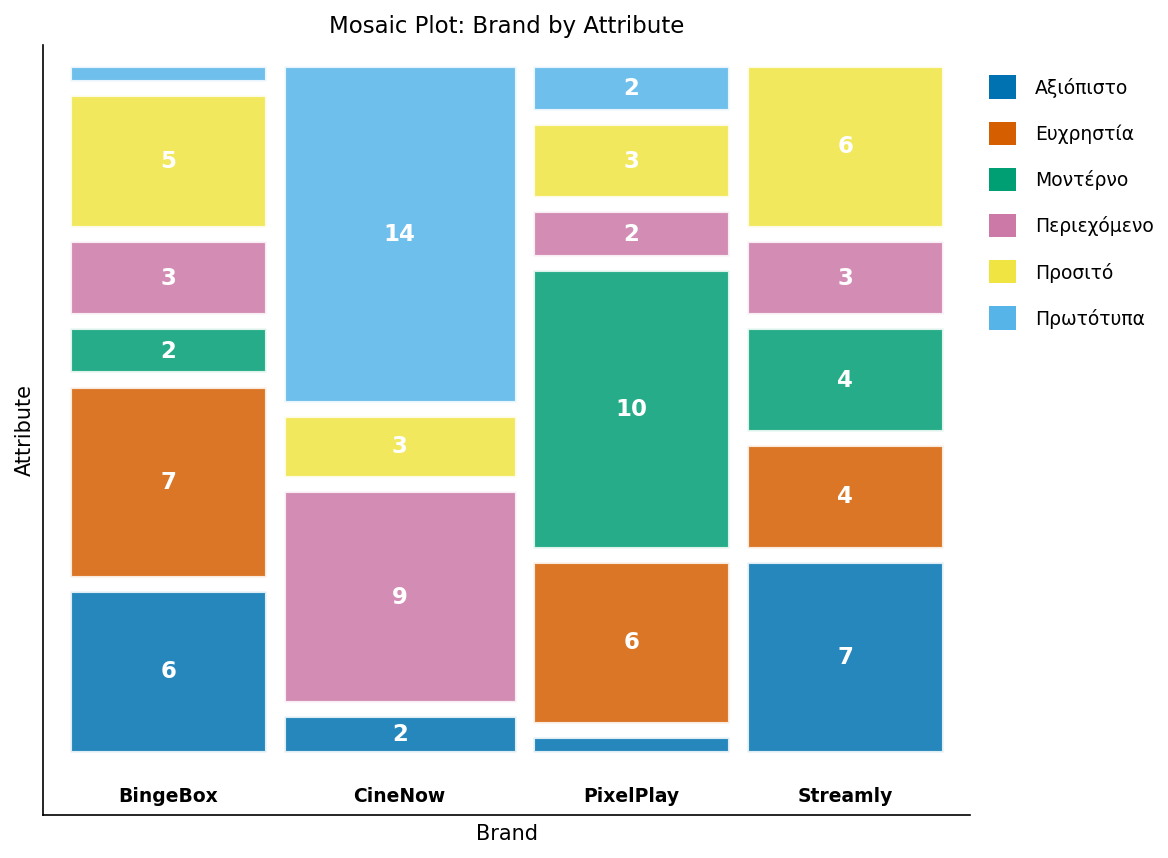

In [2]:
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=perception;
    TABLES Brand*Attribute / chisq norow nocol nopercent
                             out=survey_counts(RENAME=(count=Count));
    ΕΤΙΚΕΤΑ Brand='Επωνυμία' Attribute='Χαρακτηριστικό';
    TITLE 'Παρατηρούμενες Συχνότητες Επωνυμίας x Χαρακτηριστικού';
ΕΚΤΕΛΕΣΗ;

## Βήμα 3 — Ανάλυση αντιστοιχιών από τα ακατέργαστα δεδομένα

Τώρα εκτελούμε το `PROC CORRESP` απευθείας στα δεδομένα επιπέδου ερωτώμενου. Το `TABLES Brand, Attribute;` κατασκευάζει τον πίνακα συνάφειας εσωτερικά (επωνυμίες ως γραμμές, χαρακτηριστικά ως στήλες).

Επιλογές που χρησιμοποιούνται εδώ:

- `ALL` — τύπωσε τα πλήρη διαγνωστικά: παρατηρούμενος πίνακας, προφίλ, αναμενόμενες τιμές και   συνεισφορές χ-τετραγώνου κελιών.
- `DIMENS=2` — υπολόγισε τους δύο πρώτους κύριους άξονες (έναν δισδιάστατο χάρτη).
- `OUTC=` — γράψε τις συντεταγμένες γραμμών και στηλών σε ένα σύνολο δεδομένων για σχεδίαση.

Η **αποσύνθεση της αδράνειας** μας λέει πόση από τη συνολική συσχέτιση εξηγεί κάθε άξονας.

In [3]:
ΔΙΑΔΙΚΑΣΙΑ corresp ΔΕΔΟΜΕΝΑ=perception ALL dimens=2 outc=ca_coords;
    TABLES Brand, Attribute;
    ΕΤΙΚΕΤΑ Brand='Επωνυμία' Attribute='Χαρακτηριστικό';
    TITLE 'Ανάλυση Αντιστοιχιών: Αντίληψη Επωνυμιών Streaming';
ΕΚΤΕΛΕΣΗ;

                                 Παρατηρούμενες Συχνότητες Επωνυμίας x Χαρακτηριστικού                                  

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Επωνυμία                Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207

       


NOTE: PROC CORRESP data=perception

NOTE: PROC CORRESP completed.


## Βήμα 4 — Ανάγνωση των συντεταγμένων

Το σύνολο δεδομένων `OUTC=` κρατά τις συντεταγμένες αξόνων (`Dim1`, `Dim2`) για κάθε επωνυμία και χαρακτηριστικό, με ετικέτα από το `_TYPE_` (`ROW` για επωνυμίες, `COLUMN` για χαρακτηριστικά). Διαβάζοντάς τες αριθμητικά παράλληλα με τον πίνακα αδράνειας επιβεβαιώνεται η δομή που θα δείξει ο χάρτης.

Από την έξοδο παραπάνω:

- Η **Διάσταση 1 (75.0% της αδράνειας)** είναι ένας άξονας *premium περιεχομένου έναντι mainstream*.   Τα *Πρωτότυπα* (Dim1 = -1.2037) και *Περιεχόμενο* (-0.5594) βρίσκονται στο αρνητικό   άκρο με την **CineNow** (-1.0847)· τα *Μοντέρνο* (0.6671), *Ευχρηστία* (0.6150) και   *Προσιτό* (0.2207) βρίσκονται στο θετικό άκρο.
- Η **Διάσταση 2 (25.0% της αδράνειας)** διαχωρίζει τα *Αξιόπιστο* (Dim2 = 0.5874) και   *Προσιτό* (0.2542) — τραβώντας προς τα πάνω τις **Streamly** (0.3207) και **BingeBox** (0.3555) —   από το *Μοντέρνο* (-0.7003), που τραβά προς τα κάτω την **PixelPlay** (-0.6374).

In [4]:
ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=ca_coords noobs;
    ΜΕΤΑΒΛΗΤΗ _TYPE_ _NAME_ Dim1 Dim2;
    ΕΤΙΚΕΤΑ _NAME_='Όνομα' Dim1='Διάσταση 1' Dim2='Διάσταση 2';
    TITLE 'Συντεταγμένες Γραμμών (Επωνυμία) και Στηλών (Χαρακτηριστικό)';
ΕΚΤΕΛΕΣΗ;

                              Συντεταγμένες Γραμμών (Επωνυμία) και Στηλών (Χαρακτηριστικό)                              

_TYPE_                                Όνομα          Διάσταση 1          Διάσταση 2
ROW     BingeBox                                         0.3547              0.3555
ROW     CineNow                                         -1.0847             -0.0332
ROW     PixelPlay                                        0.4804             -0.6374
ROW     Streamly                                         0.4304              0.3207
COLUMN  Αξιόπιστο                                        0.3183              0.5874
COLUMN  Ευχρηστία                                        0.6150             -0.0080
COLUMN  Μοντέρνο                                         0.6671             -0.7003
COLUMN  Περιεχόμενο                                     -0.5594              0.0684
COLUMN  Προσιτό                                          0.2207              0.2542
COLUMN  Πρωτότυπα                     


NOTE: PROC PRINT data=ca_coords

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Βήμα 5 — Προβολή μιας διεκδικήτριας επωνυμίας ως συμπληρωματικό σημείο

Η ομάδα αναλυτικής έχει δεδομένα παρακολούθησης για μια αναδυόμενη διεκδικήτρια, τη **NovaCast**, αλλά δεν θέλει αυτή να παραμορφώσει τον καθιερωμένο αντιληπτικό χάρτη. Ένα *συμπληρωματικό* σημείο προβάλλεται στον υπάρχοντα χώρο CA **χωρίς να συνεισφέρει στον υπολογισμό των αξόνων**.

Προσθέτουμε ένα μεμονωμένο μπλοκ έξι αριθμών χαρακτηριστικών NovaCast (μιας νεοεισερχόμενης με κλίση προς Μοντέρνο / Πρωτότυπα) στα προ-συγκεντρωμένα `survey_counts`, τροφοδοτούμε τις συχνότητες με `WEIGHT Count`, και ονομάζουμε το **επίπεδο** `NovaCast` στην εντολή `SUPPLEMENTARY` ώστε το PROC CORRESP να κρατήσει αυτή τη γραμμή εκτός του ενεργού πίνακα. Η επιλογή `OBSERVED` διατηρεί τον ενεργό πίνακα συνάφειας (τις τέσσερις καθιερωμένες επωνυμίες, που αθροίζουν 100) σε προβολή — σημειώστε ότι η NovaCast **δεν** εμφανίζεται σε αυτόν, επιβεβαιώνοντας ότι αντιμετωπίστηκε ως συμπληρωματική.

In [5]:
/* Append ONE clean block of NovaCast counts to the aggregated cells.
   end=last fires the block exactly once, after the last survey_counts row,
   so NovaCast contributes six rows (one per attribute) -- not a duplicated
   block. NovaCast is a Trendy / Original-Shows-led newcomer. */
ΔΕΔΟΜΕΝΑ survey_counts_sup;
    ΟΡΙΣΜΟΣ survey_counts ΤΕΛΟΣ=last;
    ΕΞΟΔΟΣ;
    ΕΑΝ last ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
        Brand='NovaCast'; Attribute='Μοντέρνο';          Count=10; ΕΞΟΔΟΣ;
        Brand='NovaCast'; Attribute='Πρωτότυπα';  Count=8;  ΕΞΟΔΟΣ;
        Brand='NovaCast'; Attribute='Ευχρηστία';     Count=5;  ΕΞΟΔΟΣ;
        Brand='NovaCast'; Attribute='Περιεχόμενο';   Count=3;  ΕΞΟΔΟΣ;
        Brand='NovaCast'; Attribute='Προσιτό';      Count=4;  ΕΞΟΔΟΣ;
        Brand='NovaCast'; Attribute='Αξιόπιστο';        Count=3;  ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ corresp ΔΕΔΟΜΕΝΑ=survey_counts_sup observed dimens=2 outc=ca_coords_sup;
    TABLES Brand, Attribute;
    ΒΑΡΟΣ Count;
    supplementary NovaCast;
    ΕΤΙΚΕΤΑ Brand='Επωνυμία' Attribute='Χαρακτηριστικό';
    TITLE 'Αντίληψη Επωνυμιών με τη NovaCast ως Συμπληρωματικό Σημείο';
ΕΚΤΕΛΕΣΗ;

                              Συντεταγμένες Γραμμών (Επωνυμία) και Στηλών (Χαρακτηριστικό)                              

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Επωνυμία                Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207
  NovaCa


NOTE: DATA survey_counts_sup


NOTE: Read 21 rows from survey_counts.
NOTE: Wrote survey_counts_sup (27 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC CORRESP data=survey_counts_sup

NOTE: PROC CORRESP completed.


## Βήμα 6 — Σχεδίαση του αντιληπτικού χάρτη

Το PROC CORRESP γράφει τις συμμετρικές συντεταγμένες γραμμών/στηλών στο σύνολο δεδομένων `OUTC=`· σχεδιάζουμε τη Διάσταση 2 έναντι της Διάστασης 1 για να αποδώσουμε τον χάρτη. Επισημαίνουμε κάθε σημείο με τον **ρόλο** του — *Επωνυμία* (ενεργές γραμμές), *Χαρακτηριστικό* (στήλες) και *Διεκδικητής* (η συμπληρωματική γραμμή NovaCast) — και ονοματίζουμε κάθε δείκτη, ώστε η θέση να διαβάζεται απευθείας από το γράφημα. Ο διεκδικητής χρωματίζεται ξεχωριστά για να υπογραμμιστεί ότι προβλήθηκε, δεν προσαρμόστηκε.

> **Πώς να διαβάσετε έναν χάρτη CA.** Μια επωνυμία και ένα χαρακτηριστικό που βρίσκονται στην ίδια κατεύθυνση από την αρχή (και μακριά από αυτήν) συσχετίζονται ισχυρά· τα σημεία κοντά στην αρχή είναι "μέσα" και ασθενώς διαφοροποιημένα. Επειδή οι Διαστάσεις 1 και 2 μαζί συλλαμβάνουν το 100% της αδράνειας αυτού του πίνακα, ο χάρτης δεν παραλείπει τίποτα.

                Χάρτης Αντίληψης Επωνυμιών Streaming (Διάσταση 1 75.0%, Διάσταση 2 25.0% της αδράνειας)                 

PROC SGSCATTER Output
Data: ca_map

Variables: Role, _NAME_, Dim1, Dim2

      Role      _NAME_        Dim1        Dim2
----------  ----------  ----------  ----------
  Επωνυμία    BingeBox      0.3547      0.3555
  Επωνυμία     CineNow     -1.0847     -0.0332
  Επωνυμία   PixelPlay      0.4804     -0.6374
  Επωνυμία    Streamly      0.4304      0.3207
Διεκδικητής    NovaCast      0.0084     -0.1735
Χαρακτηριστικό   Αξιόπιστο      0.3183      0.5874
Χαρακτηριστικό   Ευχρηστία       0.615      -0.008
Χαρακτηριστικό    Μοντέρνο      0.6671     -0.7003
Χαρακτηριστικό  Περιεχόμενο     -0.5594      0.0684
Χαρακτηριστικό     Προσιτό      0.2207      0.2542
Χαρακτηριστικό   Πρωτότυπα     -1.2037     -0.2084

Dim1: N=11, Min=-1.2037, Max=0.6671, Mean=0.0225, Sum=0.2472
Dim2: N=11, Min=-0.7003, Max=0.5874, Mean=-0.0159, Sum=-0.1746



NOTE: DATA ca_map


NOTE: Read 11 rows from ca_coords_sup.
NOTE: Wrote ca_map (11 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Χάρτης Αντίληψης Επωνυμιών Streaming (Διάσταση 1 75.0%, Διάσταση 2 25.0% της αδράνειας).
NOTE: ODS Graphics is ON (width=760px, height=580px, format=SVG).
NOTE: PROC SGSCATTER data=ca_map

NOTE: PROC SGSCATTER output written to: ./ods_output/sgscatter.svg
NOTE: ODS Graphics is OFF.


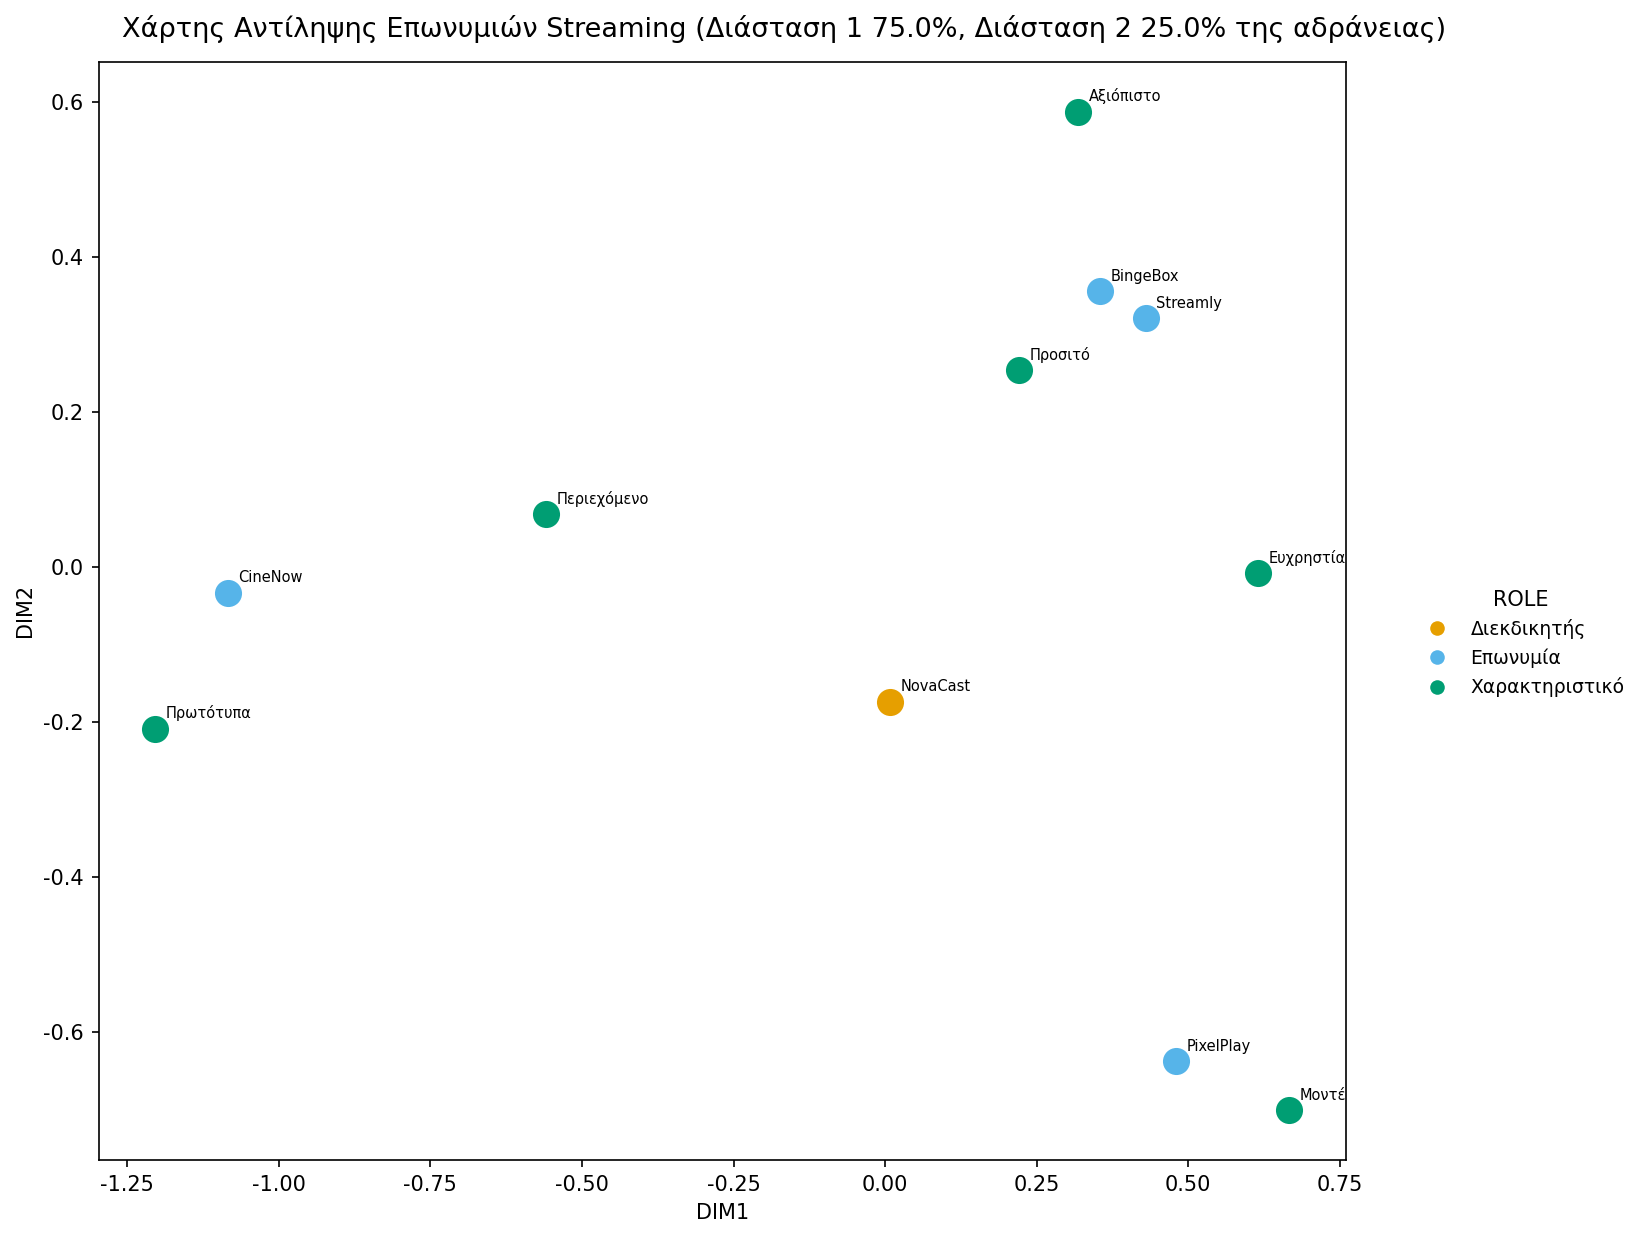

In [6]:
/* Tag each OUTC point by role for a clean, colored legend.
   Supplementary NovaCast is written to OUTC with _TYPE_='ROW',
   so we special-case it as the Challenger. */
ΔΕΔΟΜΕΝΑ ca_map;
    ΟΡΙΣΜΟΣ ca_coords_sup;
    LENGTH Role $30;
    ΕΑΝ _NAME_ = 'NovaCast' ΤΟΤΕ Role = 'Διεκδικητής';
    ΑΛΛΙΩΣ ΕΑΝ _TYPE_ = 'ROW' ΤΟΤΕ Role = 'Επωνυμία';
    ΑΛΛΙΩΣ Role = 'Χαρακτηριστικό';
    ΚΡΑΤΗΣΗ Role _NAME_ Dim1 Dim2;
ΕΚΤΕΛΕΣΗ;

/* Set the map's title globally before the PROC so it titles this
   plot (the global TITLE drives the ODS graphic's heading). */
TITLE 'Χάρτης Αντίληψης Επωνυμιών Streaming (Διάσταση 1 75.0%, Διάσταση 2 25.0% της αδράνειας)';

ODS GRAPHICS ON / WIDTH=760px HEIGHT=580px;

/* PROC CORRESP has no native ODS map in this build, so we render the
   symmetric coordinates with PROC SGSCATTER, which labels each point. */
ΔΙΑΔΙΚΑΣΙΑ SGSCATTER ΔΕΔΟΜΕΝΑ=ca_map;
    PLOT Dim2*Dim1 / GROUP=Role DATALABEL=_NAME_
                     MARKERATTRS=(size=12) grid;
ΕΚΤΕΛΕΣΗ;

ODS GRAPHICS OFF;
TITLE;

## Ερμηνεία των αποτελεσμάτων

**Η συσχέτιση είναι υπαρκτή και πλήρως συλληφθείσα.** Ο έλεγχος χ-τετραγώνου (63.15 με 15 βαθμούς ελευθερίας, p < 0.0001· V του Cramer = 0.4588) απορρίπτει την ανεξαρτησία, και οι δύο διαστάσεις CA εξηγούν το **100%** της αδράνειας του πίνακα (75.0% + 25.0%), οπότε ο παρακάτω χάρτης είναι μια πλήρης σύνοψη, όχι μια απωλεστική προβολή.

**Τρεις αντιληπτικές επικράτειες.** Διαβάζοντας τις συντεταγμένες και τον χάρτη μαζί:

- **Premium περιεχόμενο (αριστερά).** Η *CineNow* (Dim1 = -1.0847) τραβιέται πολύ αριστερά από τα   *Πρωτότυπα* (-1.2037) και *Περιεχόμενο* (-0.5594) — κατέχει την   αντίληψη βάθους καταλόγου.
- **Αξία & αξιοπιστία (πάνω δεξιά).** Η *Streamly* (0.4304, 0.3207) και η *BingeBox*   (0.3547, 0.3555) συγκεντρώνονται με τα *Προσιτό* (0.2207, 0.2542) και *Αξιόπιστο* (0.3183,   0.5874) — το αξιόπιστο ζεύγος καλής αξίας.
- **Μοδάτο (κάτω δεξιά).** Η *PixelPlay* (0.4804, -0.6374) βρίσκεται δίπλα στο *Μοντέρνο*   (0.6671, -0.7003) — η νεανική, της στιγμής επωνυμία.

**Ο συμπληρωματικός διεκδικητής.** Προβεβλημένη χωρίς να επηρεάζει τους άξονες, η **NovaCast** προσγειώνεται στο (0.0084, -0.1735) — ουσιαστικά στην αρχή των αξόνων, ωθημένη προς την πλευρά Μοντέρνο / Ευχρηστία. Για έναν στρατηγικό μέσων αυτό είναι το κύριο μήνυμα: ο διεκδικητής δεν έχει ακόμη διακριτή αξία επωνυμίας και παρασύρεται στη μοδάτη επικράτεια της PixelPlay, οπότε δικαιολογείται μια διαφοροποιημένη τοποθέτηση (παρά μια μιμητική).

**Επιφυλάξεις.** Η ανάλυση αντιστοιχιών είναι περιγραφική, όχι επαγωγική — οι αποστάσεις είναι προσεγγιστικές και τα *πρόσημα* των αξόνων είναι αυθαίρετα (μια κατοπτρική αναστροφή οποιουδήποτε άξονα είναι ο ίδιος χάρτης). Με μόλις 100 συσχετίσεις ερωτώμενου-χαρακτηριστικού, δύο κελιά είναι μηδέν (CineNow x Ευχρηστία, Streamly x Πρωτότυπα), κάτι που οξύνει τα άκρα· μια μελέτη παραγωγής θα διεξήγαγε ένα μεγαλύτερο δείγμα. Πάντα να συνδυάζετε τον χάρτη με τον πίνακα αδράνειας για να επιβεβαιώσετε πόση συσχέτιση εξηγούν οι εμφανιζόμενες διαστάσεις.